In [12]:
!pip install opencv-python tqdm

In [14]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
!ls /content/drive/MyDrive

 brain_dataset	   'Lec-1   ER Model.gdoc'	       Task02_Heart
'Colab Notebooks'  'S24CSEU1998 IMS Certificate.pdf'


In [17]:
TRAIN_DIR = "/content/drive/MyDrive/brain_dataset/Training"
TEST_DIR = "/content/drive/MyDrive/brain_dataset/Testing"

In [18]:
!ls /content/drive/MyDrive/brain_dataset/Training

glioma	meningioma  notumor  pituitary


In [19]:
TRAIN_DIR = "/content/drive/MyDrive/brain_dataset/Training"
TEST_DIR = "/content/drive/MyDrive/brain_dataset/Testing"

IMG_SIZE = 128
BATCH_SIZE = 8

In [20]:
def generate_mask(img):

    img = (img * 255).astype(np.uint8)

    blur = cv2.GaussianBlur(img, (5,5), 0)

    _, mask = cv2.threshold(
        blur,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    mask = mask / 255.0

    return mask.astype(np.float32)

In [22]:
def load_image(path):

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img = img.astype(np.float32) / 255.0

    mask = generate_mask(img)

    img = np.expand_dims(img, axis=-1)
    mask = np.expand_dims(mask, axis=-1)

    return img, mask

In [23]:
def data_generator(folder):

    classes = os.listdir(folder)

    while True:

        for cls in classes:

            cls_path = os.path.join(folder, cls)

            for fname in os.listdir(cls_path):

                if fname.endswith(".jpg"):

                    path = os.path.join(cls_path, fname)

                    img, mask = load_image(path)

                    yield img, mask

In [24]:
train_ds = tf.data.Dataset.from_generator(
    lambda: data_generator(TRAIN_DIR),
    output_signature=(
        tf.TensorSpec(shape=(IMG_SIZE,IMG_SIZE,1), dtype=tf.float32),
        tf.TensorSpec(shape=(IMG_SIZE,IMG_SIZE,1), dtype=tf.float32)
    )
)

train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [25]:
def UNet(input_shape=(128,128,1)):

    inputs = tf.keras.layers.Input(input_shape)

    c1 = tf.keras.layers.Conv2D(32,3,activation='relu',padding='same')(inputs)
    c1 = tf.keras.layers.Conv2D(32,3,activation='relu',padding='same')(c1)
    p1 = tf.keras.layers.MaxPool2D()(c1)

    c2 = tf.keras.layers.Conv2D(64,3,activation='relu',padding='same')(p1)
    c2 = tf.keras.layers.Conv2D(64,3,activation='relu',padding='same')(c2)
    p2 = tf.keras.layers.MaxPool2D()(c2)

    b = tf.keras.layers.Conv2D(128,3,activation='relu',padding='same')(p2)
    b = tf.keras.layers.Conv2D(128,3,activation='relu',padding='same')(b)

    u1 = tf.keras.layers.UpSampling2D()(b)
    u1 = tf.keras.layers.concatenate([u1,c2])
    c3 = tf.keras.layers.Conv2D(64,3,activation='relu',padding='same')(u1)

    u2 = tf.keras.layers.UpSampling2D()(c3)
    u2 = tf.keras.layers.concatenate([u2,c1])
    c4 = tf.keras.layers.Conv2D(32,3,activation='relu',padding='same')(u2)

    outputs = tf.keras.layers.Conv2D(1,1,activation='sigmoid')(c4)

    model = tf.keras.Model(inputs, outputs)

    return model

In [26]:
def dice_coef(y_true,y_pred):

    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(y_true*y_pred)

    return (2*intersection + 1) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + 1
    )

def dice_loss(y_true,y_pred):
    return 1 - dice_coef(y_true,y_pred)

In [27]:
model = UNet()

model.compile(
    optimizer='adam',
    loss=dice_loss,
    metrics=[dice_coef]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 128, 128,  │      9,248 │ conv2d_9[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 64, 64,    │          0 │ conv2d_10[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 64, 64,    │     36,928 │ conv2d_11[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 32,    │          0 │ conv2d_12[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_3[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 32, 32,    │    147,584 │ conv2d_13[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_2     │ (None, 64, 64,    │          0 │ conv2d_14[0][0]   │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 64, 64,    │          0 │ up_sampling2d_2[… │
│ (Concatenate)       │ 192)              │            │ conv2d_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 64, 64,    │    110,656 │ concatenate_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_3     │ (None, 128, 128,  │          0 │ conv2d_15[0][0]   │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 128, 128,  │          0 │ up_sampling2d_3[… │
│ (Concatenate)       │ 96)               │            │ conv2d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 128, 128,  │     27,680 │ concatenate_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 128, 128,  │         33 │ conv2d_16[0][0]   │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 424,801 (1.62 MB)

 Trainable params: 424,801 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.fit(
    train_ds,
    steps_per_epoch=200,
    epochs=20
)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 93s 343ms/step - dice_coef: 0.9189 - loss: 0.0811
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 40s 202ms/step - dice_coef: 0.9706 - loss: 0.0294
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 51s 255ms/step - dice_coef: 0.9654 - loss: 0.0346
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 19s 93ms/step - dice_coef: 0.9655 - loss: 0.0345
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - dice_coef: 0.9824 - loss: 0.0176
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - dice_coef: 0.9799 - loss: 0.0201
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - dice_coef: 0.9609 - loss: 0.0391
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - dice_coef: 0.9821 - loss: 0.0179
Epoch 9/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 19s 94ms/step - dice_coef: 0.9803 - loss: 0.0197
Epoch 10/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 19s 96ms/step - dice_coef: 0.9752 - loss: 0.0248
Epoch 11/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - dice_coef: 0.9704 - loss: 0.0296
Epoch 12/20
200

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


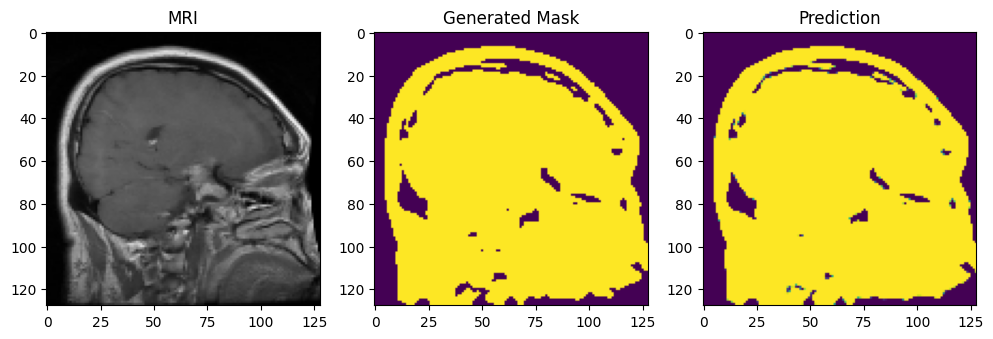

In [33]:
import random

def get_random_test_image_path(test_dir):
    classes = os.listdir(test_dir)
    if not classes:
        raise ValueError("No classes found in the test directory.")

    random_class = random.choice(classes)
    class_path = os.path.join(test_dir, random_class)

    images = [f for f in os.listdir(class_path) if f.endswith(".jpg")]
    if not images:
        raise ValueError(f"No JPG images found in the class: {random_class}")

    random_image = random.choice(images)
    return os.path.join(class_path, random_image)

sample_image_path = get_random_test_image_path(TEST_DIR)
img, mask = load_image(sample_image_path)

pred = model.predict(img[np.newaxis,...])[0]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img.squeeze(), cmap="gray")
plt.title("MRI")

plt.subplot(1,3,2)
plt.imshow(mask.squeeze())
plt.title("Generated Mask")

plt.subplot(1,3,3)
plt.imshow(pred.squeeze())
plt.title("Prediction")

plt.show()

In [34]:
import numpy as np

def dice_score(y_true, y_pred):

    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    intersection = np.sum(y_true * y_pred)

    return (2 * intersection) / (np.sum(y_true) + np.sum(y_pred) + 1e-8)

In [36]:
# First, load all test images and masks into X_test and y_test
num_test_images = 0
for cls in os.listdir(TEST_DIR):
    cls_path = os.path.join(TEST_DIR, cls)
    num_test_images += len([f for f in os.listdir(cls_path) if f.endswith(".jpg")])

X_test_list = []
y_test_list = []
test_gen = data_generator(TEST_DIR)

for _ in range(num_test_images):
    img_data, mask_data = next(test_gen)
    X_test_list.append(img_data)
    y_test_list.append(mask_data)

X_test = np.array(X_test_list)
y_test = np.array(y_test_list)

y_pred = model.predict(X_test)

# convert probabilities → binary mask
y_pred = (y_pred > 0.5).astype(np.uint8)

41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step


In [37]:
dice_scores = []

for i in range(len(X_test)):
    dice = dice_score(y_test[i], y_pred[i])
    dice_scores.append(dice)

print("Average Dice Score:", np.mean(dice_scores))

Average Dice Score: 0.9641791915277792


In [38]:
from sklearn.metrics import confusion_matrix

y_true_flat = y_test.flatten()
y_pred_flat = y_pred.flatten()

cm = confusion_matrix(y_true_flat, y_pred_flat)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10501733   694995]
 [   63389 10219307]]


In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_true_flat, y_pred_flat))

              precision    recall  f1-score   support

         0.0       0.99      0.94      0.97  11196728
         1.0       0.94      0.99      0.96  10282696

    accuracy                           0.96  21479424
   macro avg       0.97      0.97      0.96  21479424
weighted avg       0.97      0.96      0.96  21479424



In [40]:
def iou_score(y_true, y_pred):

    intersection = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)

    return np.sum(intersection) / (np.sum(union) + 1e-8)


ious = []

for i in range(len(X_test)):
    ious.append(iou_score(y_test[i], y_pred[i]))

print("Average IoU:", np.mean(ious))

Average IoU: 0.9390353426058355


In [41]:
idx = np.random.randint(0, len(X_test))

dice = dice_score(y_test[idx], y_pred[idx])

print("Dice Score for this image:", dice)

Dice Score for this image: 0.996204133276498


In [42]:
model.save("brain_segmentation_model.h5")

In [43]:
from google.colab import files
files.download("brain_segmentation_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>